## All Packages needed

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import os

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import scipy.ndimage
from scipy import misc
from glob import glob
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
import skimage
import imageio
import seaborn as sns
from PIL import Image
import glob
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
device

/tmp/ipykernel_1412442/3122316970.py:14: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


device(type='cuda', index=2)

# Data loading & inspection
## Getting shape of CSV file
## And summary of data types

In [3]:
#Getting a summary of the number of images and the different class IDs

df = pd.read_csv('archive/labels_train.csv')
df.shape
df


,file_name,class_id
0,img_4358977458434011046.jpg,1
1,img_5224016757187192130.jpg,2
2,img_3065202206106254707.jpg,2
3,img_6304894865561547174.jpg,1
4,img_3371338542810939877.jpg,2
...,...,...
4667,img_6661311872293090412.jpg,2
4668,img_3844568579349757418.jpg,1
4669,img_9145812369383814369.jpg,1
4670,img_1311393330250392648.jpg,1


In [4]:
# Need to create folders for each X-ray type to store the images
types = df['class_id'].unique()
print(types)

[1 2 0]


# Feature-level analysis

## There are 3 image classes:

Class 0: no disease

Class 1: bacterial pneumonia

Class 2: viral pneumonia

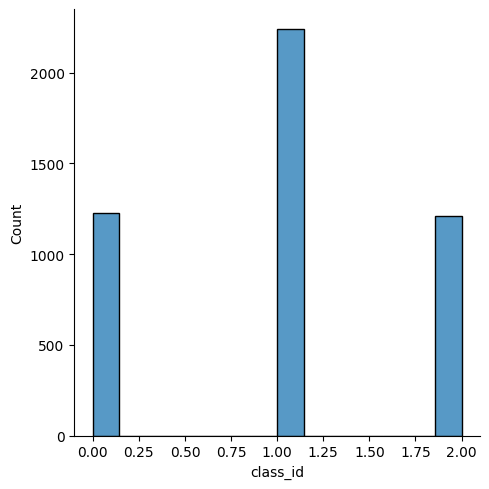

In [5]:
#visualization displot of the different classes and their image counts

sns.displot(df['class_id'])
plt.show()

## Discuss any class imbalance, possible bias, noise

There are many more bacterial image X-rays of pneumonia than there are normal and viral X-rays. We
fix this class imbalance with class weights.

## Missing values, outliers, duplicates

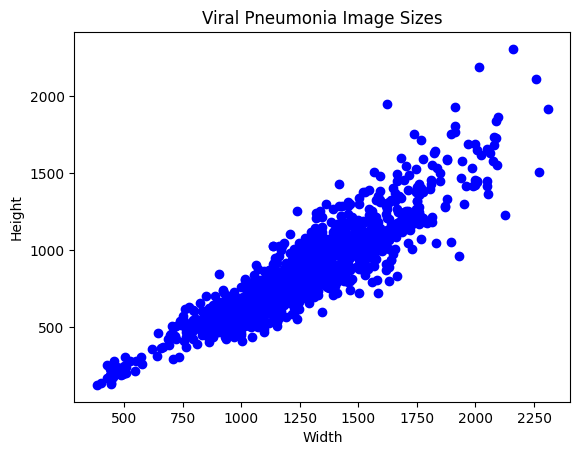

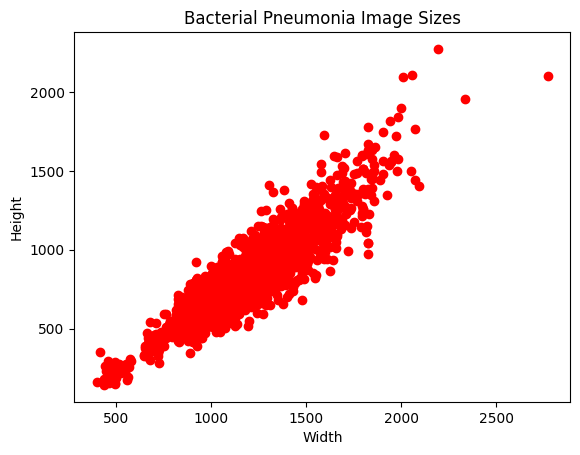

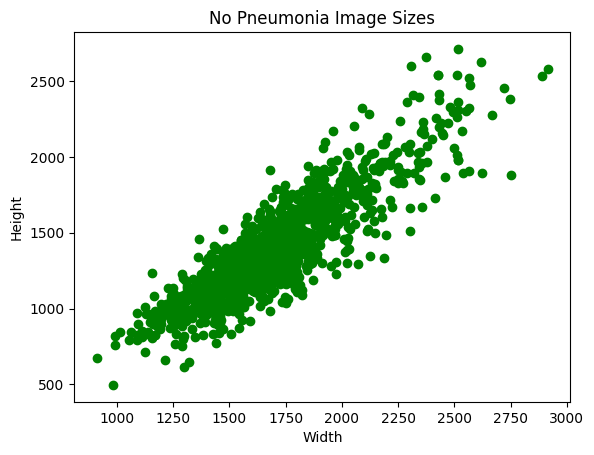

In [6]:
from PIL import Image
import os
import matplotlib.pyplot as plt

# Class folders inside final_train
base_dir = 'final_train'
classes = ['viral_pneumonia', 'bacterial_pneumonia', 'no_pneumonia']

vp_w, vp_h = [], []
bp_w, bp_h = [], []
np_w, np_h = [], []

for label in classes:
    folder_path = os.path.join(base_dir, label)
    
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)
        image = Image.open(image_path)
        w, h = image.size

        if label == 'viral_pneumonia':
            vp_w.append(w)
            vp_h.append(h)
        elif label == 'bacterial_pneumonia':
            bp_w.append(w)
            bp_h.append(h)
        else:
            np_w.append(w)
            np_h.append(h)

# Plot viral pneumonia sizes
plt.scatter(vp_w, vp_h, color='blue')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("Viral Pneumonia Image Sizes")
plt.show()

# Plot bacterial pneumonia sizes
plt.scatter(bp_w, bp_h, color='red')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("Bacterial Pneumonia Image Sizes")
plt.show()

# Plot no pneumonia sizes
plt.scatter(np_w, np_h, color='green')
plt.xlabel('Width')
plt.ylabel('Height')
plt.title("No Pneumonia Image Sizes")
plt.show()


In [7]:
#This shows if there are any missing values in the 2 columns provided with the CSV file
df.isnull().sum()

file_name    0
class_id     0
dtype: int64

## Calculating class weights

This is to compensate for the class imbalance seen with the histogram.

In [8]:
# sizes of each class
classes = df['class_id'].unique()
total_images = df.shape[0]
class_weights = {}
class_frequencies = []

for c in classes:
    class_weights[c] = df['class_id'].value_counts().get(c, 0)
    class_frequencies.append(class_weights[c]/total_images)
    class_weights[c] = class_weights[c]/total_images

class_median = np.median(class_frequencies)

for c in class_weights:
    class_weights[c] = class_median/class_weights[c]
    print(f"{c} : {class_weights[c]}")

1 : 0.5482573726541554
2 : 1.0165700082850042
0 : 1.0


## Placing the images in their respective folders

In [10]:
#import os
#import shutil

#disease_types = df['class_id'].unique()
#folders = {}

#for type in disease_types:
#    if type == 0:
#        folder_name = 'final_train/no_pneumonia'
#    elif type == 1:
#        folder_name = 'final_train/bacterial_pneumonia'
#    else:
#        folder_name = 'final_train/viral_pneumonia'

    # folders[type] = folder_name
    
    # if not os.path.exists(folder_name):
    #     os.makedirs(folder_name)
    # else:
    #     print("already exisits")



#each image from the chest X-ray dataset

#for filename in os.listdir('train_images/train_images'): 
#    image = df.loc[df['file_name'] == filename]
#    img_class = image['class_id'].values[0]
#    src = 'train_images/train_images/' + filename
    
#    if img_class == 0:
#        folder = "final_train/no_pneumonia"
#        file_count = NP_count
#        NP_count += 1
#    elif img_class == 1:
#        folder = "final_train/bacterial_pneumonia"
#        file_count = BP_count
#        BP_count += 1
#    else:
#        folder = "final_train/viral_pneumonia"
#         file_count = VP_count
#         VP_count += 1

    
#     dest = folder + '/' + filename
#     shutil.copy(src, dest)

# print("Done!")

# for folder in folders.values():
#     num_images = len(os.listdir(folder))
#     print(f"{folder}: {num_images} total images")

Done!
final_train/bacterial_pneumonia: 2238 total images
final_train/viral_pneumonia: 1207 total images
final_train/no_pneumonia: 1227 total images


In [11]:
# import os

# NP_count = 0
# BP_count = 0
# VP_count = 0

# # Define the full paths to each folder inside 'final_train'
# folders = {
#     "no_pneumonia": "final_train/no_pneumonia",
#     "bacterial_pneumonia": "final_train/bacterial_pneumonia",
#     "viral_pneumonia": "final_train/viral_pneumonia"
# }

# for label, folder in folders.items():
#     for filename in os.listdir(folder):
#         if label == "no_pneumonia":
#             file_count = NP_count
#             NP_count += 1
#         elif label == "bacterial_pneumonia":
#             file_count = BP_count
#             BP_count += 1
#         else: 
#             label == "viral_pneumonia"
#             file_count = VP_count
#             VP_count += 1

#         old_name = os.path.join(folder, filename)
#         new_name = os.path.join(folder, f"{label}_{file_count}.jpg")

#         os.rename(old_name, new_name)


# Visualization

Shows examples in each folder

## For image data: grid samples

We are a little limited with what we can visualize as our metadata only has the image class id and what image it corresponds to


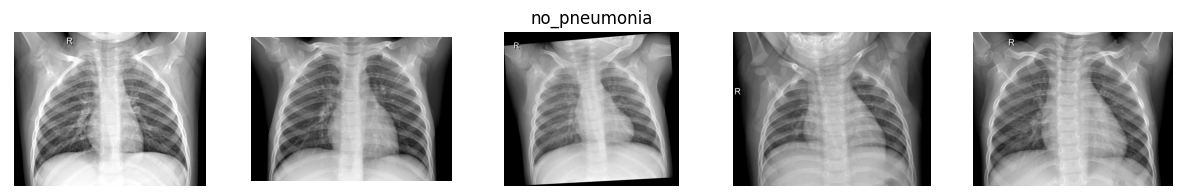

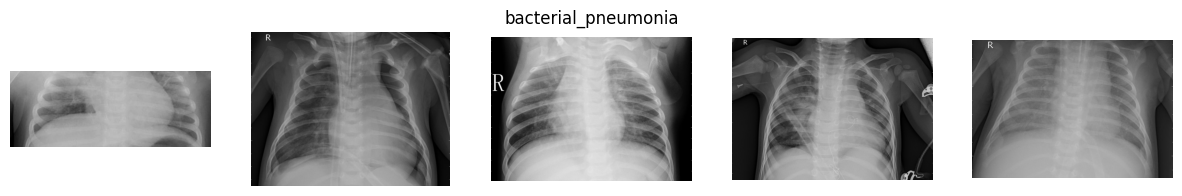

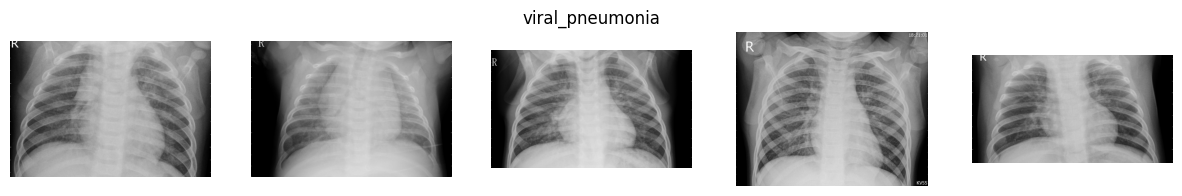

In [12]:
import os
import matplotlib.pyplot as plt

# Define the base directory
base_dir = 'final_train'

# Class folder names
classes = ['no_pneumonia', 'bacterial_pneumonia', 'viral_pneumonia']

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)
    
    plt.figure(figsize=(15, 2))
    plt.title(class_name)
    plt.axis('off')

    # Display 5 sample images from each class
    for i in range(5):
        img_path = os.path.join(folder_path, os.listdir(folder_path)[i])
        img = plt.imread(img_path)
        
        plt.subplot(1, 5, i + 1)
        plt.axis('off')
        plt.imshow(img, cmap="gray")
    
    plt.show()


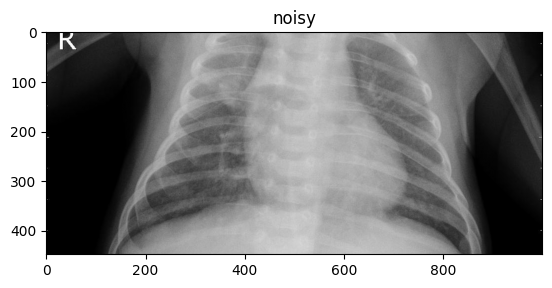

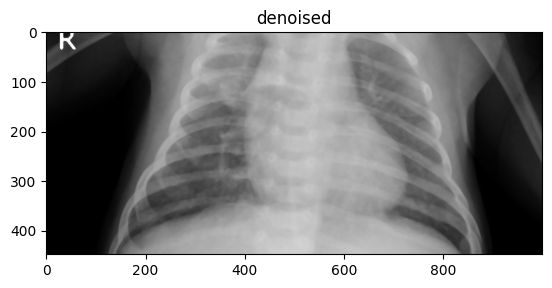

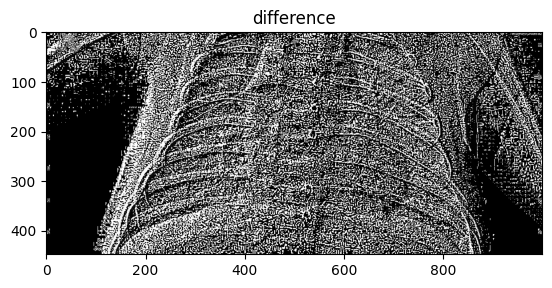

In [13]:
noisy_img = Image.open("final_train/viral_pneumonia/viral_pneumonia_100.jpg")
plt.title("noisy")
plt.imshow(noisy_img, cmap="gray")
plt.show()

filtered_img = scipy.ndimage.median_filter(noisy_img, size=6)
plt.title("denoised")
plt.imshow(filtered_img, cmap="gray")
plt.show()

diff_img = np.abs(filtered_img - noisy_img)
plt.title("difference")
plt.imshow(diff_img, cmap="gray")
plt.show()
#shows the noisy denoised and difference between them of a viral pneumonia image


## Preprocessing Plan
What needs fixing before modeling?

Using Resize and horizontal flip were crucial to using this training dataset. There were other transformations that were used to slightly modify the training dataset and make sure the model wasn't memorizing this dataset. With jitter random affine, grayscale, normalize, and random rotation the training dataset is made diverse enough so that it can generalize well. There are some commented out transformations. These were tested and found to have negative impact on the accuracies of the model. There were also fewer transformations used on the test and validation dataset. This was to improve prediction accuracies but also make sure the model doesn't memorize these.

In [14]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from collections import Counter




train_transform = transforms.Compose([
    #transforms.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.95, 1.05)),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    #transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=40),  #Slightly reduce rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  #Add subtle variation
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),  #Slight shift
    transforms.Grayscale(num_output_channels=3), # Convert 1-channel -> 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),  #Normalize to match grayscale spread
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

# Load the full dataset from a single clean folder
whole_dataset = ImageFolder(root='final_train')

# Split into training, test, and validation sets (70%, 20%, and 10% worked best for my model)
total_size = len(whole_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size


train_indices, val_indices, test_indices = random_split(
    range(total_size), [train_size, val_size, test_size]
)

# Use Subset with specific transforms for each split
train_dataset = torch.utils.data.Subset(ImageFolder(root='final_train', transform=train_transform), train_indices)
val_dataset = torch.utils.data.Subset(ImageFolder(root='final_train', transform=val_transform), val_indices)
test_dataset = torch.utils.data.Subset(ImageFolder(root='final_train', transform=val_transform), test_indices) #using the val transformations for both

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=10) #increased number of workers and batchfile for quicker better results
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)


def count_classes(subset, name):
    labels = [subset.dataset.samples[i][1] for i in subset.indices]
    counts = Counter(labels)
    print(f"\n{name} class distribution:")
    for class_idx in range(len(subset.dataset.classes)):
        print(f"Class {class_idx}: {counts[class_idx]}")

# Count in each dataset
count_classes(train_dataset, "Train")
count_classes(val_dataset, "Validation")
count_classes(test_dataset, "Test")

#################################### UN-COMMENT FOLLOWING CODE IF PULLING MODEL FROM WEB ####################################
'''
from torch import nn

num_classes = len(classes)
net = torchvision.models.resnet18(pretrained = True)

# We replace last layer of resnet to match our number of classes which is 7
net.fc = nn.Linear(512, num_classes)
net = net.to(device)
'''



Train class distribution:
Class 0: 1576
Class 1: 851
Class 2: 843

Validation class distribution:
Class 0: 439
Class 1: 252
Class 2: 243

Test class distribution:
Class 0: 223
Class 1: 124
Class 2: 121


'\nfrom torch import nn\n\nnum_classes = len(classes)\nnet = torchvision.models.resnet18(pretrained = True)\n\n# We replace last layer of resnet to match our number of classes which is 7\nnet.fc = nn.Linear(512, num_classes)\nnet = net.to(device)\n'

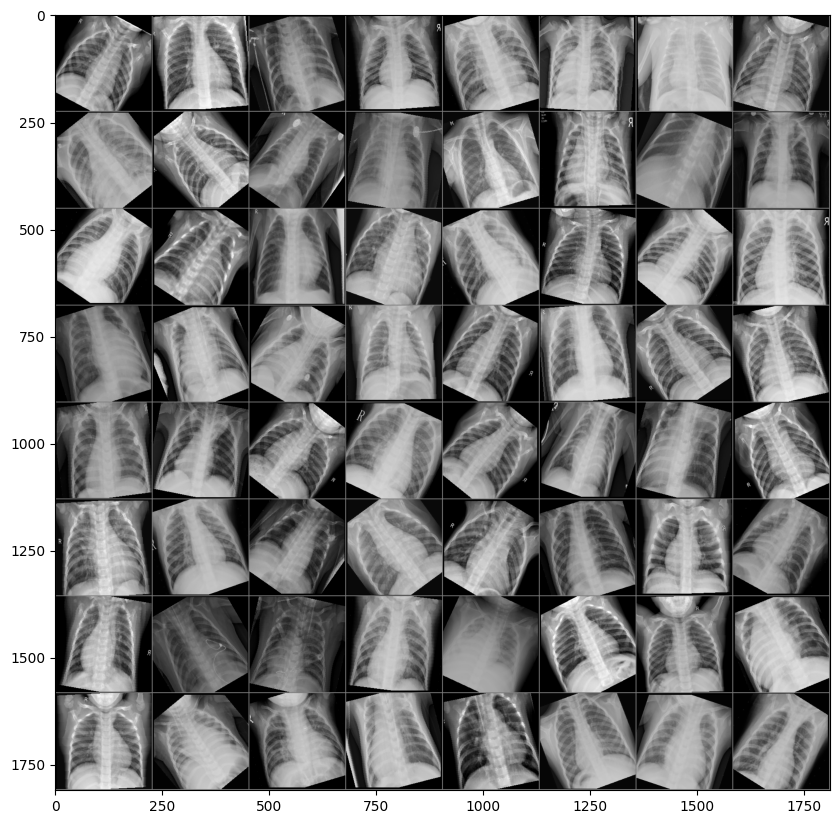

bacterial_pneumonia,  bacterial_pneumonia,  no_pneumonia,  bacterial_pneumonia,  viral_pneumonia,  no_pneumonia,  viral_pneumonia,  bacterial_pneumonia,  no_pneumonia,  bacterial_pneumonia,  no_pneumonia,  viral_pneumonia,  bacterial_pneumonia,  no_pneumonia,  viral_pneumonia,  viral_pneumonia,  no_pneumonia,  no_pneumonia,  no_pneumonia,  no_pneumonia,  no_pneumonia,  bacterial_pneumonia,  bacterial_pneumonia,  viral_pneumonia,  no_pneumonia,  no_pneumonia,  no_pneumonia,  viral_pneumonia,  viral_pneumonia,  no_pneumonia,  bacterial_pneumonia,  bacterial_pneumonia,  viral_pneumonia,  no_pneumonia,  bacterial_pneumonia,  viral_pneumonia,  bacterial_pneumonia,  no_pneumonia,  no_pneumonia,  bacterial_pneumonia,  no_pneumonia,  viral_pneumonia,  no_pneumonia,  bacterial_pneumonia,  no_pneumonia,  no_pneumonia,  bacterial_pneumonia,  viral_pneumonia,  no_pneumonia,  no_pneumonia,  viral_pneumonia,  viral_pneumonia,  no_pneumonia,  bacterial_pneumonia,  bacterial_pneumonia,  viral_pneumoni

In [15]:
# functions to show an image
fig = plt.figure(figsize=(10, 15))
def imshow(img):
    img = img / 2 + 0.5     # denormalize change this
    img = torch.clamp(img, 0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show() #had to add this to ensure the images are shown
    

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter) #had to change this for the new way pytorch DataLoader works

# show images
imshow(torchvision.utils.make_grid(images))

# print labels
print(' '.join('%5s, ' % classes[labels[j]] for j in range(len(labels))))

# DenseNet121
This model has been fine tuned. Any leftover/ commented out code were attempts at improving the model but ultimately led to no change in accuracy or worse accuracy. These comments are kept in the jupyter notebook file so that no repeated attempts at improving with failed strategies are made.

In [16]:
from torch import nn
import torchvision


net = torchvision.models.densenet121(pretrained = True) #loading pretrained densenet121 

#for param in net.features.parameters():
#    param.requires_grad = False

# Replace last layer of DenseNet121 to match our number of classes
num_ftrs = net.classifier.in_features
net.classifier = nn.Linear(num_ftrs, 3)  # 3 classes

#net.classifier = nn.Sequential(
#    nn.Linear(num_ftrs, 512),
#    nn.ReLU(),
#    nn.Dropout(0.5),
#    nn.Linear(512, 3)
#)

net = net.to(device) #copying the net to this device (which is cuda/gpu and if that isn't an option cpu)

/home/public/ekittell/COMP5300_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/public/ekittell/COMP5300_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
import torch.optim as optim

# Assuming class_weights is a dict like: {0: 1.0, 1: 2.5, ..., n: w}
# Convert it to a list or tensor in the correct order
weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight = class_weights_tensor) #using cross entropy loss with class weights for data class imbalance
#optimizer = optim.Adam(net.parameters(), lr=1e-5) #Adam optimizer is being used with learning rate of 1e-5 model.parameters(), 
optimizer = optim.Adam(net.parameters(),lr=1e-5)
print(net) #printing the network with these additions

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [18]:
from sklearn.metrics import accuracy_score

#helper functions for computing accuracy
def get_accuracy(predicted, labels):
    #tensor of predicted labels and tensor of true labels
    batch_len, correct= 0, 0
    #determines the batch size
    batch_len = labels.size(0)
    #comparing the predicted with the true labels to get the number of correct predictions
    correct = (predicted == labels).sum().item()
    #returning the batch size and the number of correct predictions
    return batch_len, correct

#function for evaluating the model on validation dataset
def evaluate(model, val_loader):
    #trained neural network and the validation data loader
    losses= 0
    num_samples_total=0
    #set up variables for evaluation
    correct_total=0
    #set model to evaluation mode
    model.eval()
    #iterating through validation dataset
    for inputs, labels in val_loader:
        #move input data and labels to device (cuda/GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)
        #determine predicted class
        _, predicted = torch.max(out, 1)
        #calculate loss
        loss = criterion(out, labels)
        losses += loss.item() 
        #count correct predictions
        b_len, corr = get_accuracy(predicted, labels)
        num_samples_total +=b_len
        #add up total correct
        correct_total +=corr
    #calculate accuracy
    accuracy = correct_total/num_samples_total
    #calculate loss
    losses = losses/len(val_loader)
    #return both
    return losses, accuracy

In [19]:
# number of loops over the dataset
num_epochs = 30 #30 epoch was the sweet spot for MY MODEL ONLY this gave me the best accuracy at this epoch
#set up arrays for accuracy
accuracy = []
val_accuracy = []
#set up arrays for losses
losses = []
val_losses = []

#training loop for the number of epocs specified
for epoch in range(num_epochs):
    #variable for monitoring training loss
    running_loss = 0.0
    #monitors for accuracy
    correct_total= 0.0
    num_samples_total=0.0
    #loop for iterating through training dataset
    for i, data in enumerate(train_loader):
        # get the inputs
        inputs, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        # set the parameter gradients to zero
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        #calculate loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        #compute accuracy
        _, predicted = torch.max(outputs, 1)
        #using get_accuracy function to count the correct predictions
        b_len, corr = get_accuracy(predicted, labels)
        num_samples_total +=b_len
        #calculating the total correct predictions
        correct_total +=corr
        #calculating the total training loss
        running_loss += loss.item()

    #getting running loss and training accuracy
    running_loss /= len(train_loader)
    train_accuracy = correct_total/num_samples_total
    val_loss, val_acc = evaluate(net, val_loader)
    
    #print epochs
    print('Epoch: %d' %(epoch+1))
    #print training loss and accuracy
    print('Loss: %.3f  Accuracy:%.3f' %(running_loss, train_accuracy))
    #print validating loss and accuracy
    print('Validation Loss: %.3f  Val Accuracy: %.3f' %(val_loss, val_acc))

    #add all these loss/accuracy measurments to their respective arrays for later use
    losses.append(running_loss)
    val_losses.append(val_loss)
    accuracy.append(train_accuracy)
    val_accuracy.append(val_acc)
#print message to signify end of training loop
print('Finished Training')

Epoch: 1
Loss: 0.964  Accuracy:0.597
Validation Loss: 0.864  Val Accuracy: 0.682
Epoch: 2
Loss: 0.633  Accuracy:0.746
Validation Loss: 0.537  Val Accuracy: 0.794
Epoch: 3
Loss: 0.553  Accuracy:0.783
Validation Loss: 0.601  Val Accuracy: 0.764
Epoch: 4
Loss: 0.528  Accuracy:0.791
Validation Loss: 0.580  Val Accuracy: 0.786
Epoch: 5
Loss: 0.506  Accuracy:0.806
Validation Loss: 0.493  Val Accuracy: 0.814
Epoch: 6
Loss: 0.484  Accuracy:0.814
Validation Loss: 0.458  Val Accuracy: 0.823
Epoch: 7
Loss: 0.474  Accuracy:0.815
Validation Loss: 0.468  Val Accuracy: 0.820
Epoch: 8
Loss: 0.463  Accuracy:0.815
Validation Loss: 0.484  Val Accuracy: 0.823
Epoch: 9
Loss: 0.456  Accuracy:0.822
Validation Loss: 0.487  Val Accuracy: 0.812
Epoch: 10
Loss: 0.470  Accuracy:0.818
Validation Loss: 0.506  Val Accuracy: 0.823
Epoch: 11
Loss: 0.435  Accuracy:0.835
Validation Loss: 0.447  Val Accuracy: 0.836
Epoch: 12
Loss: 0.421  Accuracy:0.831
Validation Loss: 0.470  Val Accuracy: 0.825
Epoch: 13
Loss: 0.441  Ac

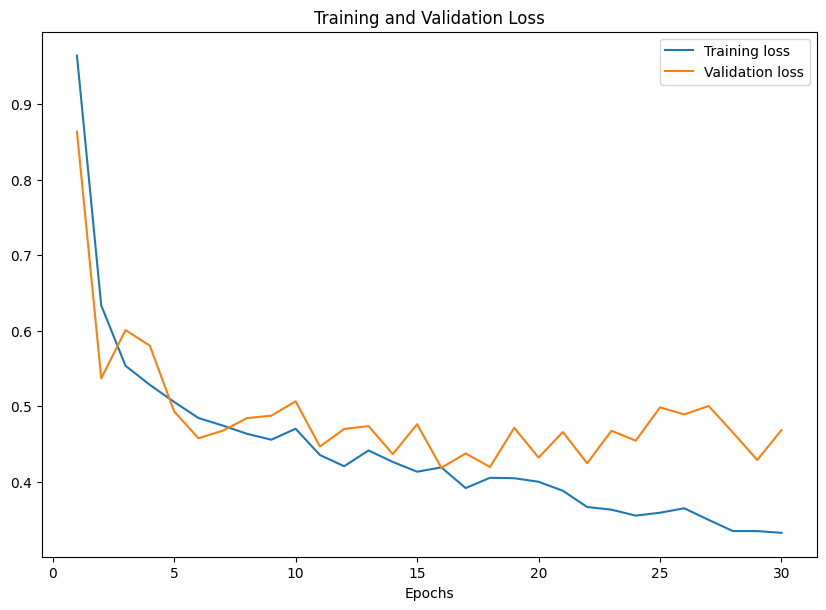

<Figure size 640x480 with 0 Axes>

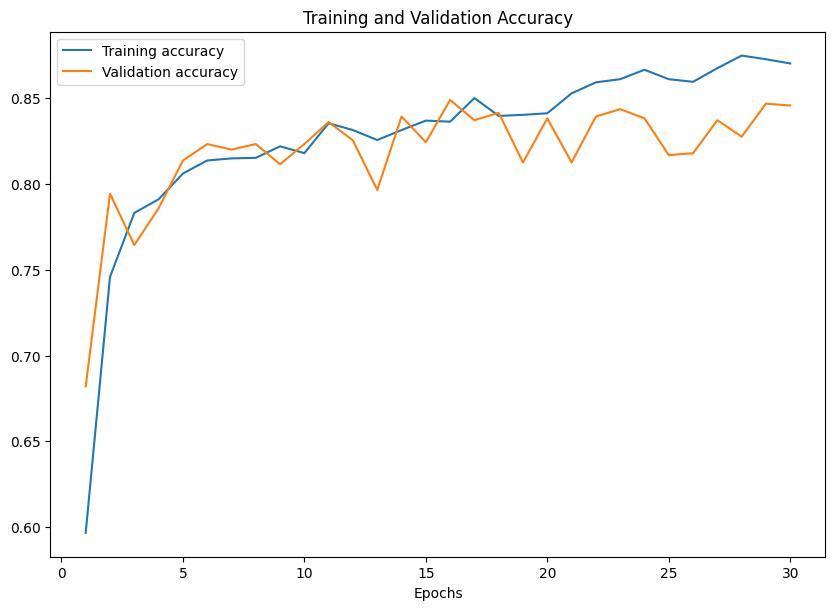

<Figure size 640x480 with 0 Axes>

In [20]:
# plt.plot(losses)
# plt.show()

#get epoch range for x axis of graph
epoch = range(1, num_epochs+1)
#set up a figure size 10x15 for our data
fig = plt.figure(figsize=(10, 15))
plt.subplot(2,1,2)
#plot measurements of training loss and validation loss
plt.plot(epoch, losses, label='Training loss')
plt.plot(epoch, val_losses, label='Validation loss')
#title for figure
plt.title('Training and Validation Loss')
#set epochs as x axis label
plt.xlabel('Epochs')
#create legend for different measurements
plt.legend()
plt.figure()
#show plot below notebook cell
plt.show()

#set up another figure
fig = plt.figure(figsize=(10, 15))
plt.subplot(2,1,2)
#plot both training accuracy and validation accuracy
plt.plot(epoch, accuracy, label='Training accuracy')
plt.plot(epoch, val_accuracy, label='Validation accuracy')
#set title
plt.title('Training and Validation Accuracy')
#set x axis title
plt.xlabel('Epochs')
#make legend for measurements
plt.legend()
plt.figure()
#show plot below cell
plt.show()

# TEST DATASET ACCURACIES
Testing the model on the test dataset to get a final indication of whether fine tuning is working properly. Some past training runs have shown that validation and training accuracies can be inflated. Test dataset accuracy is the final indication of the model's success. In this case for DenseNet 80% accuracy on the test dataset seems to be average.

In [21]:
#variables for counting correct predictions
correct = 0
#total predictions
total = 0
net.eval()
with torch.no_grad():
    #loop for data in the test dataset
    for data in test_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
         #compute accuracy
        _, predicted = torch.max(outputs.data, 1)
        #get total number of labels
        total += labels.size(0)
        #add up correct predictions
        correct += (predicted == labels).sum().item()

#print accuracy
print('Accuracy of the network on the test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the test images: 80 %


In [22]:
#make two lists for tracking accuracy of each class
class_correct = list(0. for i in range(len(classes)))
class_total = list(1e-7 for i in range(len(classes)))
with torch.no_grad():
    #loop for data in the test data loader
    for data in test_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        #compute accuracy
        _, predicted = torch.max(outputs, 1)
        #using compare predicted with true label
        c = (predicted == labels).squeeze()
        #loop for adding to class correct and class total
        for i in range(3):
            label = labels[i]
            #adding to the correct predictions and total predictions for each class
            class_correct[label] += c[i].item()
            class_total[label] += 1

#printing the accuracy of each class
for i in range(len(classes)):
    print('Accuracy of %5s : %2d %%' % (
        #printing class and % out of 100
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of no_pneumonia : 91 %
Accuracy of bacterial_pneumonia : 99 %
Accuracy of viral_pneumonia : 49 %


In [23]:
#create confusion matric with size x and y of classes
confusion_matrix = torch.zeros(len(classes), len(classes))
with torch.no_grad():
    #loop for data in the test data loader
    for data in test_loader:
        images, labels = data
        #move input data and labels to device (cuda/GPU or CPU)
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        #get predicted for accuracy
        _, predicted = torch.max(outputs, 1)
        #updates confusion matrix based on if a predicted label is the same as the true label
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1

#output confusion matrix as data below code cell
print(confusion_matrix)
cm = confusion_matrix.numpy()

tensor([[184.,   2.,  37.],
        [  3., 119.,   2.],
        [ 39.,   7.,  75.]])


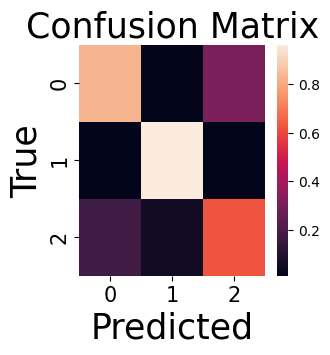

In [24]:
#set up figure to visually display data
fig,ax= plt.subplots(figsize=(3,3))
#create seaborn heatmap for visualizing confusion matrix
sns.heatmap(cm / (cm.astype(np.float64).sum(axis=1) + 1e-9), annot=False, ax=ax) #changed to float64

# labels, title and ticks
ax.set_xlabel('Predicted', size=25);
#setting x and y labels
ax.set_ylabel('True', size=25); 
#set title
ax.set_title('Confusion Matrix', size=25); 
#setting all labels for all classes in x and y axis
ax.xaxis.set_ticklabels(['0', '1', '2'], size=15); 
ax.yaxis.set_ticklabels(['0', '1', '2'], size=15);

plt.show() #added this

# ALL SUPPORT FOR GRADCAM
Support for gradcam to check that fine-tuning helps the model understand where to look when making a prediction. IF THE MODEL IS LOOKING OUTSIDE OF THE CHEST X RAY there are problems with the chest X-ray data augmentation. With the final results most gradcam outcomes show focus in the lung areas which is ideal.

In [25]:
from collections import OrderedDict

#class for the model to support grad cam computation
class _BaseWrapper(object):
    """
    Please modify forward() and backward() according to your task.
    """
    #constructor for model
    def __init__(self, model):
        super(_BaseWrapper, self).__init__()
        #getting the models device either cuda/GPU or CPU
        self.device = next(model.parameters()).device
        #getting model
        self.model = model
        self.handlers = []  # a set of hook function handlers

    #creates one hot encoded tensor for the target class
    def _encode_one_hot(self, ids):
        one_hot = torch.zeros_like(self.logits).to(self.device)
        #used to specify which class to compute gradients in backpropagation seen later
        one_hot.scatter_(1, ids, 1.0)
        return one_hot

    #feeds an image forward through the model
    def forward(self, image):
        """
        Simple classification
        """
        self.model.zero_grad() #resetting gradient
        self.logits = self.model(image)
        self.probs = F.softmax(self.logits, dim=1) #convert logits to probability
        return self.probs.sort(dim=1, descending=True) #return probabilities

    def backward(self, ids):
        """
        Class-specific backpropagation
        Either way works:
        1. self.logits.backward(gradient=one_hot, retain_graph=True)
        2. (self.logits * one_hot).sum().backward(retain_graph=True)
        """

        one_hot = self._encode_one_hot(ids) #convert target class into one hot encoding
        self.logits.backward(gradient=one_hot, retain_graph=True) #gradient computation

    #raises an error for not implemented (maybe this is a left over function or smth?)
    def generate(self):
        raise NotImplementedError

    #freeing hooks
    def remove_hook(self):
        """
        Remove all the forward/backward hook functions
        """
        for handle in self.handlers:
            handle.remove() #removing hooks to free memory

#gradcam class that extends the basewrapper class
class GradCAM(_BaseWrapper):
    """
    "Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization"
    https://arxiv.org/pdf/1610.02391.pdf
    Look at Figure 2 on page 4
    """

    #constructor for GradCam class
    def __init__(self, model, candidate_layers=None):
        super(GradCAM, self).__init__(model)
        self.fmap_pool = OrderedDict() #store feature maps
        self.grad_pool = OrderedDict() #store gradients
        #storing layers
        self.candidate_layers = candidate_layers  # list

        #function for capturing the feature maps
        def forward_hook(key):
            def forward_hook_(module, input, output):
                # Save featuremaps
                self.fmap_pool[key] = output.detach()

            return forward_hook_

        #gets the gradients of the featuremaps during backpropagation
        def backward_hook(key):
            def backward_hook_(module, grad_in, grad_out):
                # Save the gradients correspond to the featuremaps
                self.grad_pool[key] = grad_out[0].detach()

            return backward_hook_

        # If any candidates are not specified, the hook is registered to all the layers.
        for name, module in self.model.named_modules():
            if self.candidate_layers is None or name in self.candidate_layers:
                self.handlers.append(module.register_forward_hook(forward_hook(name)))
                self.handlers.append(module.register_backward_hook(backward_hook(name)))

    #functuon for finding featuremaps and gradients
    def _find(self, pool, target_layer):
        if target_layer in pool.keys():
            return pool[target_layer]
        else: #raises and error otherwise
            raise ValueError("Invalid layer name: {}".format(target_layer))

    #computes gradient weights
    def _compute_grad_weights(self, grads):
        return F.adaptive_avg_pool2d(grads, 1)

    #returns averaged gradients
    def forward(self, image):
        self.image_shape = image.shape[2:]
        #calls forward method to pass image through model
        return super(GradCAM, self).forward(image)

    def generate(self, target_layer):
        #store feature maps
        fmaps = self._find(self.fmap_pool, target_layer)
        #store gradients
        grads = self._find(self.grad_pool, target_layer)
        #compute weights
        weights = self._compute_grad_weights(grads)

        gcam = torch.mul(fmaps, weights).sum(dim=1, keepdim=True)
        gcam = F.relu(gcam) #apply ReLu to get rid of negative values

        #resize image to original size
        gcam = F.interpolate(
            #upscales heatmap to original size
            gcam, self.image_shape, mode="bilinear", align_corners=False
        )

        B, C, H, W = gcam.shape
        gcam = gcam.view(B, -1)
        #normalizing to [0,1]
        gcam -= gcam.min(dim=1, keepdim=True)[0]
        gcam /= gcam.max(dim=1, keepdim=True)[0]
        gcam = gcam.view(B, C, H, W)
        #returns the heatmap image
        return gcam
    
print(net)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu


True Class: no_pneumonia


/home/public/ekittell/COMP5300_venv/lib/python3.10/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/home/public/ekittell/COMP5300_venv/lib/python3.10/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Generating Grad-CAM @features.denseblock4.denselayer16.conv2
	#0: no_pneumonia (0.83984)


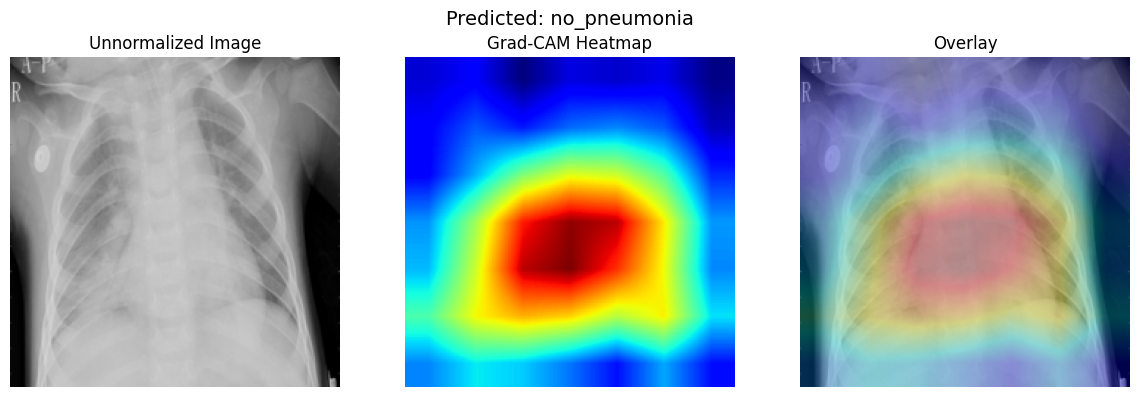


True Class: viral_pneumonia
Generating Grad-CAM @features.denseblock4.denselayer16.conv2
	#0: viral_pneumonia (0.00000)


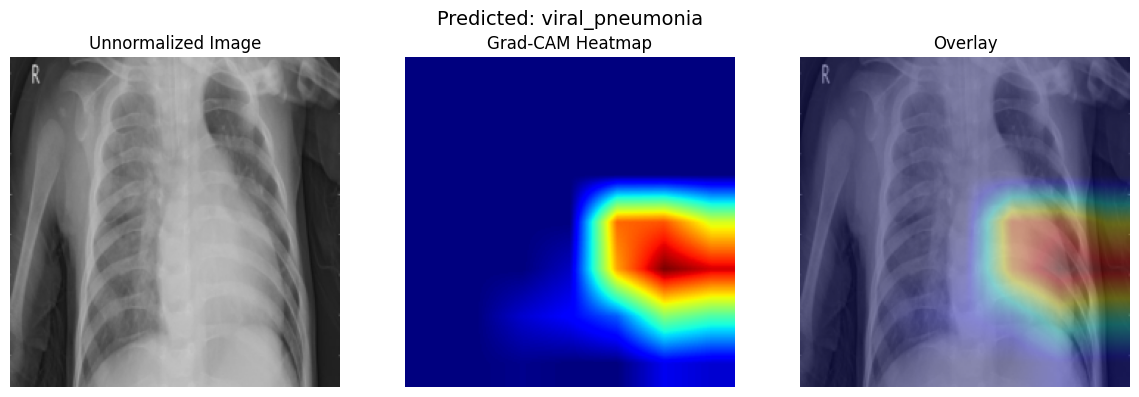


True Class: bacterial_pneumonia
Generating Grad-CAM @features.denseblock4.denselayer16.conv2
	#0: bacterial_pneumonia (0.00022)


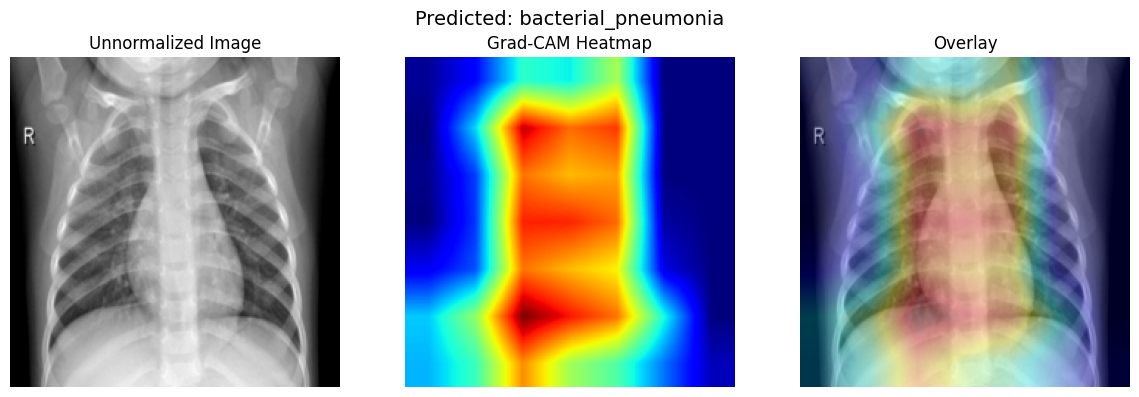

Generating Grad-CAM @features.denseblock4.denselayer16.conv2
	#0: viral_pneumonia (0.00272)


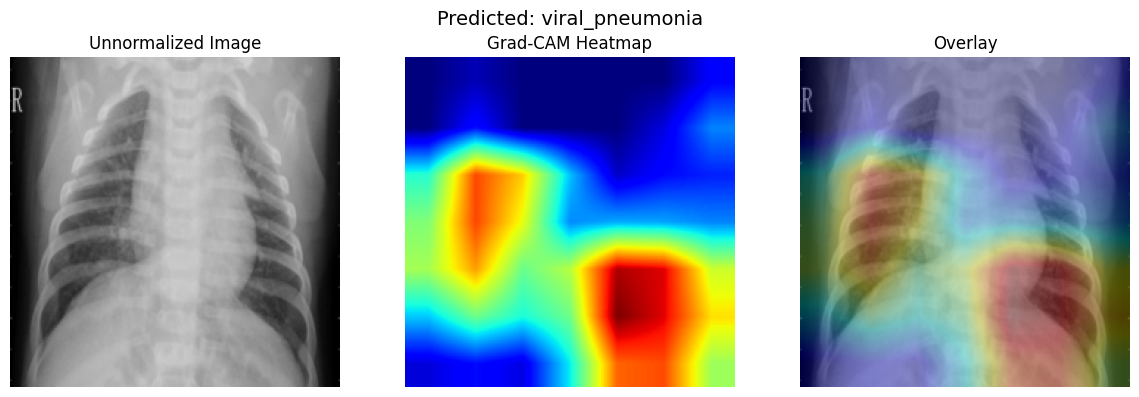

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6627451].


True Class:  viral_pneumonia


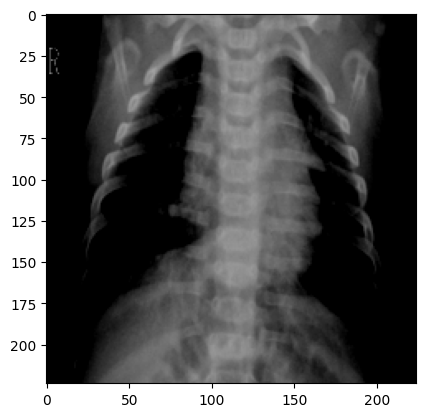

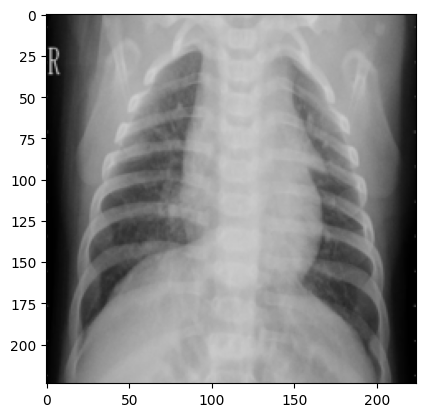

In [26]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

norm_mean = [0.5]*3
norm_std = [0.5]*3

#demo of the grad cam images
def demo2(image, label, model):
    """
    Generate Grad-CAM with overlay
    """
    #move model to correct device
    model.to(device)
    model.eval()

    target_layers = ['features.denseblock4.denselayer16.conv2']
    target_class = label.item()

    images = image.unsqueeze(0)
    gcam = GradCAM(model=model) #initialize grad cam
    probs, ids = gcam.forward(images) #passes images through the model
    ids_ = torch.LongTensor([[target_class]] * len(images)).to(device)
    gcam.backward(ids=ids_) #computing gradients for target class

    #loops over target layers
    for target_layer in target_layers:
        print("Generating Grad-CAM @{}".format(target_layer))
        regions = gcam.generate(target_layer=target_layer)  #generates gradcam heatmap

        for j in range(len(images)):
            print(
                "\t#{}: {} ({:.5f})".format(
                    j, classes[target_class], float(probs[0, target_class]) #prints class label and the probability
                )
            )

            # Grad-CAM heatmap
            gcam_region = regions[j, 0].cpu().numpy()
            gcam_resized = cv2.resize(gcam_region, (image.shape[2], image.shape[1]))
            heatmap = cv2.applyColorMap(np.uint8(255 * gcam_resized), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

            # Unnormalize image
            image_np = image.cpu().numpy().transpose(1, 2, 0)
            image_unnorm = (image_np * np.array(norm_std)) + np.array(norm_mean)
            image_unnorm = np.clip(image_unnorm, 0, 1)

            # Convert to uint8
            image_uint8 = np.uint8(255 * image_unnorm)

            # Overlay
            overlay = cv2.addWeighted(image_uint8, 0.7, heatmap, 0.3, 0)

            # Show all
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 3, 1)
            plt.imshow(image_unnorm)
            plt.title("Unnormalized Image")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(gcam_resized, cmap='jet')
            plt.title("Grad-CAM Heatmap")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(overlay)
            plt.title("Overlay")
            plt.axis("off")

            plt.suptitle(f"Predicted: {classes[target_class]}", fontsize=14)
            plt.tight_layout()
            plt.show()

# --- Run Grad-CAM for one image per class ---

# Track which classes we’ve seen
seen_classes = {cls: False for cls in range(len(classes))}

# Load the model
model = net

# Loop through validation data
for images, labels in val_loader:
    for i in range(len(labels)):
        label = labels[i].item()
        if not seen_classes[label]:
            print(f"\nTrue Class: {classes[label]}")
            image = images[i].to(device)
            label_tensor = labels[i].to(device)

            # Generate Grad-CAM visualization
            demo2(image, label_tensor, model)

            seen_classes[label] = True

    # Exit loop when we’ve visualized all classes
    if all(seen_classes.values()):
        break


image, label = next(iter(val_loader))
# Load the model
model = net
# Grad cam
demo2(image[0].to(device), label[0].to(device), model)


image = np.transpose(image[0], (1,2,0))
image2  = np.add(np.multiply(image.numpy(), np.array(norm_std)) ,np.array(norm_mean))
print("True Class: ", classes[label[0].cpu()])
plt.imshow(image)
plt.show()
plt.imshow(image2)
plt.show()